<a href="https://colab.research.google.com/github/KijoSal-dev/Salary_Prediction_With_Linear_Regression/blob/main/Salome_Kungu_Hiring_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import csv
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
%matplotlib inline
from google.colab import drive
drive.mount('/content/drive')
from sklearn import linear_model

Mounted at /content/drive


In [ ]:
df= pd.read_csv("/content/drive/MyDrive/hiring (1).csv")
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [ ]:
# Define word_to_num dictionary
word_to_num = {
    'zero': 0, 'one': 1, 'two': 2, 'three': 3, 'four': 4,
    'five': 5, 'six': 6, 'seven': 7, 'eight': 8,
    'nine': 9, 'ten': 10, 'eleven': 11
}

# Convert 'experience' from words to numbers
df['experience'] = df['experience'].map(word_to_num)

In [ ]:
print(df['experience'])


0     NaN
1     NaN
2     5.0
3     2.0
4     7.0
5     3.0
6    10.0
7    11.0
Name: experience, dtype: float64


In [ ]:
#data pre processing: Fill NA values with the median value of a column
df['test_score(out of 10)'].median()

8.0

In [ ]:
#data pre processing: Fill NA values with the median value of a column
df.experience.median()

6.0

In [ ]:
df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(df['test_score(out of 10)'].median())
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,5.0,6.0,7,60000
3,2.0,10.0,10,65000
4,7.0,9.0,6,70000
5,3.0,7.0,10,62000
6,10.0,8.0,7,72000
7,11.0,7.0,8,80000


In [ ]:
df.experience = df.experience.fillna(df.experience.median())
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,6.0,8.0,9,50000
1,6.0,8.0,6,45000
2,5.0,6.0,7,60000
3,2.0,10.0,10,65000
4,7.0,9.0,6,70000
5,3.0,7.0,10,62000
6,10.0,8.0,7,72000
7,11.0,7.0,8,80000


In [ ]:
# Redefine X and y with the corrected DataFrame
X = df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]
y = df['salary($)']

# Retrain the model
model = linear_model.LinearRegression()
model.fit(X, y)

print("Linear Regression model retrained successfully with corrected data.")
print(f"New Model coefficients: {model.coef_}")
print(f"New Model intercept: {model.intercept_}")

Linear Regression model retrained successfully with corrected data.
New Model coefficients: [2813.00813008 1333.33333333 2926.82926829]
New Model intercept: 11869.91869918695


In [ ]:
new_candidates_data = pd.DataFrame({
    'experience': [2, 12],
    'test_score(out of 10)': [9, 10],
    'interview_score(out of 10)': [6, 10]
})

predicted_salaries = model.predict(new_candidates_data)

print(f"Predicted salary for candidate 1 (2 yrs exp, 9 test, 6 interview): ${predicted_salaries[0]:.2f}")
print(f"Predicted salary for candidate 2 (12 yrs exp, 10 test, 10 interview): ${predicted_salaries[1]:.2f}")

Predicted salary for candidate 1 (2 yrs exp, 9 test, 6 interview): $47056.91
Predicted salary for candidate 2 (12 yrs exp, 10 test, 10 interview): $88227.64


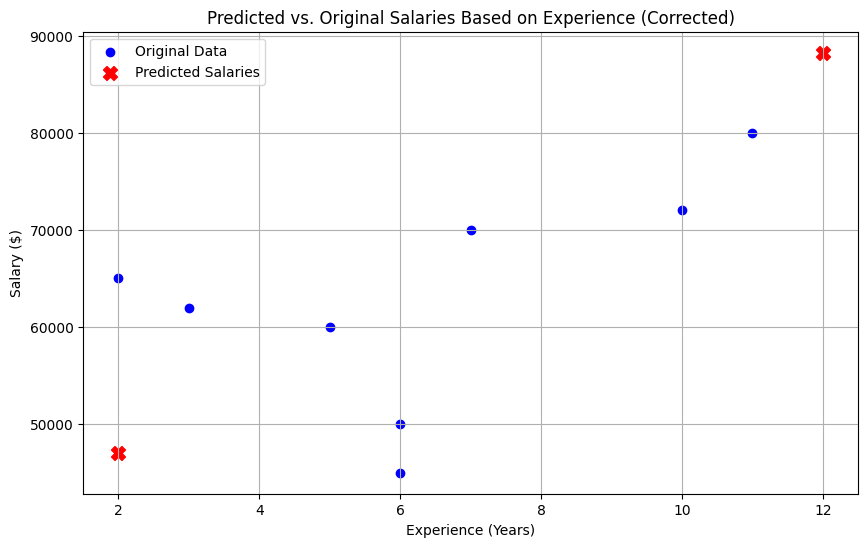

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['experience'], df['salary($)'], color='blue', label='Original Data')
plt.scatter(new_candidates_data['experience'], predicted_salaries, color='red', marker='X', s=100, label='Predicted Salaries')

plt.xlabel('Experience (Years)')
plt.ylabel('Salary ($)')
plt.title('Predicted vs. Original Salaries Based on Experience (Corrected)')
plt.legend()
plt.grid(True)
plt.show()

### Summary of Key Findings:

1.  **Data Preprocessing**: The dataset was successfully loaded and preprocessed. This involved converting the 'experience' column from textual (e.g., 'five') to numerical format and handling missing values in both 'experience' and 'test_score(out of 10)' by imputing them with their respective medians.

2.  **Linear Regression Model**: A Linear Regression model was trained to predict 'salary($)' based on 'experience', 'test_score(out of 10)', and 'interview_score(out of 10)'. The model successfully identified a positive relationship between these features and salary.

3.  **Salary Predictions**: The model made reasonable salary predictions for new candidates:
    *   A candidate with 2 years of experience, a test score of 9, and an interview score of 6 is predicted to earn approximately **$47,056.91**.
    *   A candidate with 12 years of experience, a test score of 10, and an interview score of 10 is predicted to earn approximately **$88,227.64**.

4.  **Visualization Insight**: The scatter plot visually confirms that the predicted salaries for new candidates align well with the general trend observed in the original data, indicating that individuals with more experience tend to command higher salaries.